In [ ]:
# STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully! ✅")

Libraries imported successfully! ✅


In [ ]:
# STEP 2: LOAD DATASET & PREVIEW
df = pd.read_csv("predictive_maintenance.csv")

print("Missing Values Per Column:")
print(df.isnull().sum())
print("\nDataset Info:")
df.info()

df.head()

Missing Values Per Column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torqu

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
# STEP 3: DATA PREPROCESSING
# Drop unique identifier columns
cols_to_drop = ['UDI', 'Product ID']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Handle Numerical Missing Values (if any exist)
num_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
for col in num_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

# Handle Categorical Missing Values (if any exist)
if 'Type' in df.columns and df['Type'].isnull().sum() > 0:
    df['Type'] = df['Type'].fillna(df['Type'].mode()[0])

# Check missing values again to confirm
print("Missing values after cleaning:")
print(df.isnull().sum())
df.head()

Missing values after cleaning:
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


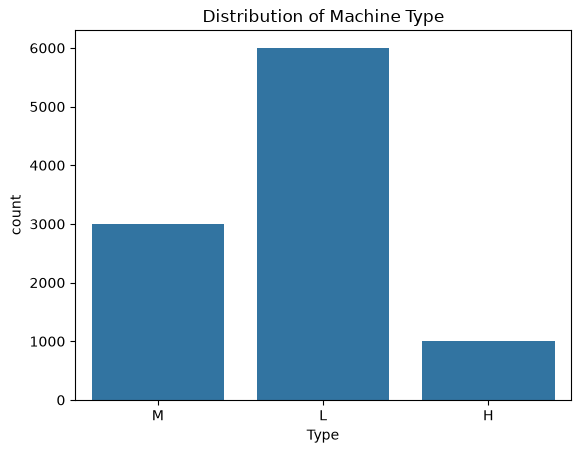

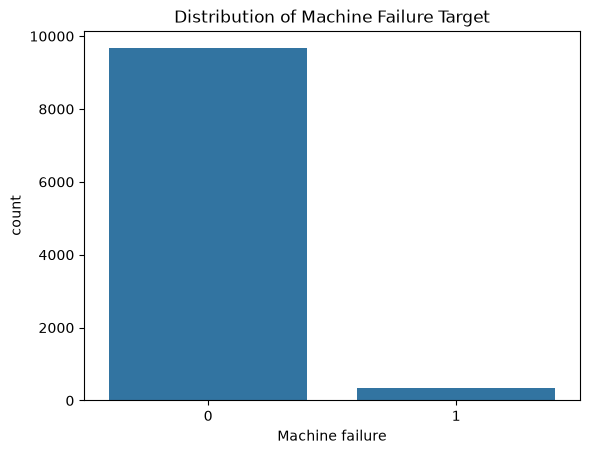

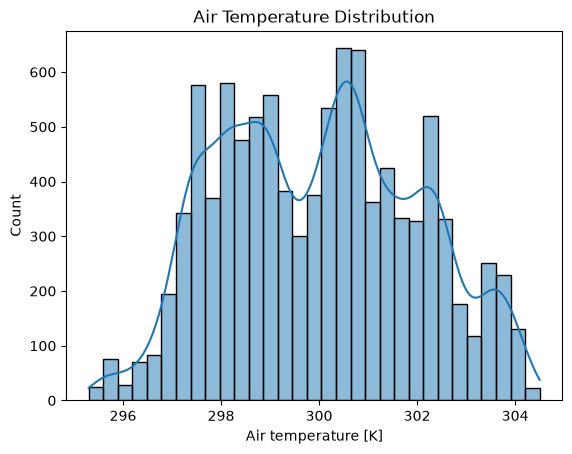

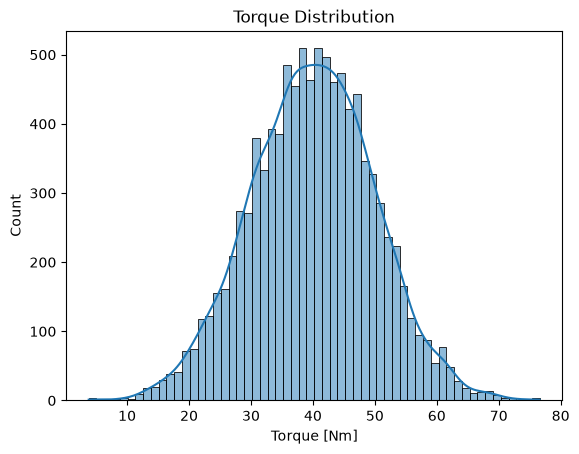

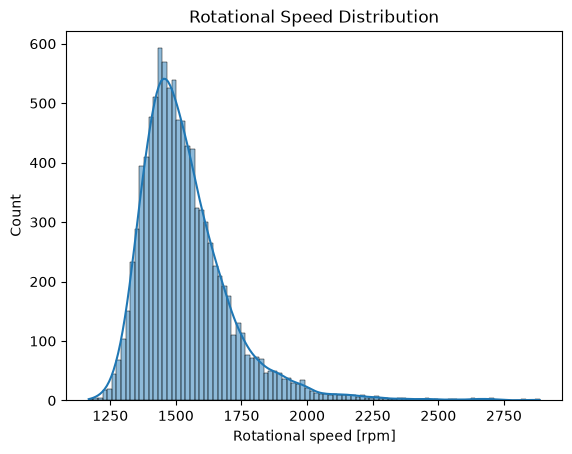

In [ ]:
# STEP 4: EXPLORATORY DATA ANALYSIS
# Categorical distribution
sns.countplot(x=df['Type'])
plt.title("Distribution of Machine Type")
plt.show()

# Target Variable Distribution
sns.countplot(x=df['Machine failure'])
plt.title("Distribution of Machine Failure Target")
plt.show()

# Numerical feature distributions
sns.histplot(df['Air temperature [K]'], kde=True)
plt.title("Air Temperature Distribution")
plt.show()

sns.histplot(df['Torque [Nm]'], kde=True)
plt.title("Torque Distribution")
plt.show()

sns.histplot(df['Rotational speed [rpm]'], kde=True)
plt.title("Rotational Speed Distribution")
plt.show()

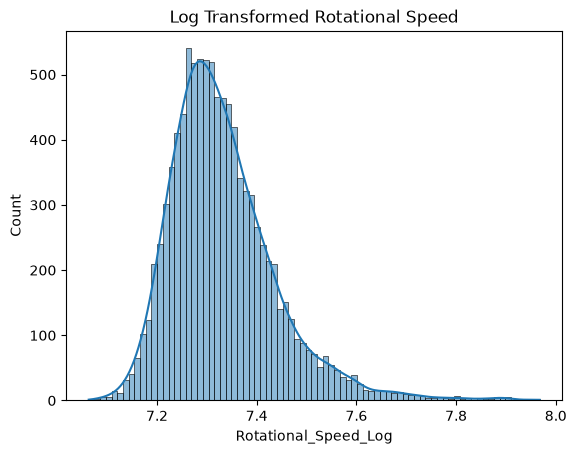

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_Diff,Power,Rotational_Speed_Log,Torque_Log,Tool_Wear_Log
0,M,298.1,308.6,1551,42.8,0,0,10.5,6.951079,7.346655,3.779634,0.000000
1,L,298.2,308.7,1408,46.3,3,0,10.5,6.826220,7.249926,3.856510,1.386294
2,L,298.1,308.5,1498,49.4,5,0,10.4,7.748817,7.311886,3.919991,1.791759
3,L,298.2,308.6,1433,39.5,7,0,10.4,5.927068,7.267525,3.701302,2.079442
4,L,298.2,308.7,1408,40.0,9,0,10.5,5.897382,7.249926,3.713572,2.302585


In [ ]:
# STEP 5: FEATURE ENGINEERING & LOG TRANSFORMS
# 1. Temperature Difference
df['Temp_Diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

# 2. Power & Stress features
df['Power'] = (df['Torque [Nm]'] * df['Rotational speed [rpm]']) / 9550

# 3. Log Transformations to reduce skewness
df['Rotational_Speed_Log'] = np.log(df['Rotational speed [rpm]'])
df['Torque_Log'] = np.log(df['Torque [Nm]'] + 1)
df['Tool_Wear_Log'] = np.log(df['Tool wear [min]'] + 1)

# Display distributions after Log transformation
sns.histplot(df['Rotational_Speed_Log'], kde=True)
plt.title("Log Transformed Rotational Speed")
plt.show()

# Drop leakage target columns (failure subtypes)
failure_subtypes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df = df.drop(columns=[col for col in failure_subtypes if col in df.columns])

df.head()

In [ ]:
# STEP 6: ENCODING CATEGORICAL FEATURES
if 'Type' in df.columns:
    # Convert 'Type' column into dummy variables
    d_type = pd.get_dummies(df['Type'], prefix='Type', drop_first=True)
    
    # Drop original 'Type' column
    df = df.drop(columns=['Type'])
    
    # Concatenate dummy columns back to dataframe
    df = pd.concat([df, d_type], axis=1)

# Ensure no duplicate column names remain
df = df.loc[:, ~df.columns.duplicated()]

print("Dataframe shape after encoding:", df.shape)
print("Columns in df:", df.columns.tolist())
df.head()

Dataframe shape after encoding: (10000, 13)
Columns in df: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Temp_Diff', 'Power', 'Rotational_Speed_Log', 'Torque_Log', 'Tool_Wear_Log', 'L', 'M']


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_Diff,Power,Rotational_Speed_Log,Torque_Log,Tool_Wear_Log,L,M
0,298.1,308.6,1551,42.8,0,0,10.5,6.951079,7.346655,3.779634,0.000000,False,True
1,298.2,308.7,1408,46.3,3,0,10.5,6.826220,7.249926,3.856510,1.386294,True,False
2,298.1,308.5,1498,49.4,5,0,10.4,7.748817,7.311886,3.919991,1.791759,True,False
3,298.2,308.6,1433,39.5,7,0,10.4,5.927068,7.267525,3.701302,2.079442,True,False
4,298.2,308.7,1408,40.0,9,0,10.5,5.897382,7.249926,3.713572,2.302585,True,False


In [ ]:
# STEP 7: SPECIFY INPUT AND OUTPUT
y = df['Machine failure']
X = df.drop(columns=['Machine failure'])

print("Target (y) value counts:")
print(y.value_counts())

print("\nFeatures (X) Preview:")
X.head()

Target (y) value counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Features (X) Preview:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff,Power,Rotational_Speed_Log,Torque_Log,Tool_Wear_Log,L,M
0,298.1,308.6,1551,42.8,0,10.5,6.951079,7.346655,3.779634,0.000000,False,True
1,298.2,308.7,1408,46.3,3,10.5,6.826220,7.249926,3.856510,1.386294,True,False
2,298.1,308.5,1498,49.4,5,10.4,7.748817,7.311886,3.919991,1.791759,True,False
3,298.2,308.6,1433,39.5,7,10.4,5.927068,7.267525,3.701302,2.079442,True,False
4,298.2,308.7,1408,40.0,9,10.5,5.897382,7.249926,3.713572,2.302585,True,False


In [ ]:
# STEP 8: SPLIT DATASET
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train.head()

X_train shape: (7500, 12)
X_test shape:  (2500, 12)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff,Power,Rotational_Speed_Log,Torque_Log,Tool_Wear_Log,L,M
9350,298.2,308.7,2186,17.8,31,10.5,4.074429,7.689829,2.933857,3.465736,True,False
1125,296.7,307.8,1375,51.4,108,11.1,7.400524,7.226209,3.958907,4.691348,False,True
2439,299.1,308.4,1693,31.6,65,9.3,5.601969,7.434257,3.484312,4.189655,True,False
5629,302.7,312.2,1405,51.4,157,9.5,7.561990,7.247793,3.958907,5.062595,True,False
2875,300.5,309.4,1877,23.8,31,8.9,4.677759,7.537430,3.210844,3.465736,False,True


In [ ]:
# STEP 9: MODEL TRAINING

# --- Model 1: Random Forest Classifier ---
model_rf = RandomForestClassifier(random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train)

rf_acc = model_rf.score(X_test, y_test) * 100
print("Random Forest Accuracy is:", rf_acc)


# --- Model 2: Decision Tree Classifier ---
model_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model_dt.fit(X_train, y_train)

dt_acc = model_dt.score(X_test, y_test) * 100
print("Decision Tree Accuracy is:", dt_acc)


# --- Model 3: Logistic Regression ---
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

lr_acc = model_lr.score(X_test, y_test) * 100
print("Logistic Regression Accuracy is:", lr_acc)

Random Forest Accuracy is: 98.83999999999999
Decision Tree Accuracy is: 98.6
Logistic Regression Accuracy is: 96.76


C:\Users\lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RANDOM FOREST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2415
           1       0.84      0.81      0.83        85

    accuracy                           0.99      2500
   macro avg       0.92      0.90      0.91      2500
weighted avg       0.99      0.99      0.99      2500

DECISION TREE CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2415
           1       0.82      0.75      0.79        85

    accuracy                           0.99      2500
   macro avg       0.91      0.87      0.89      2500
weighted avg       0.99      0.99      0.99      2500

LOGISTIC REGRESSION CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2415
           1       0.56      0.22      0.32        85

    accuracy                           0.97      2500
   macro av

C:\Users\lenovo\AppData\Local\Temp\ipykernel_540\950871657.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


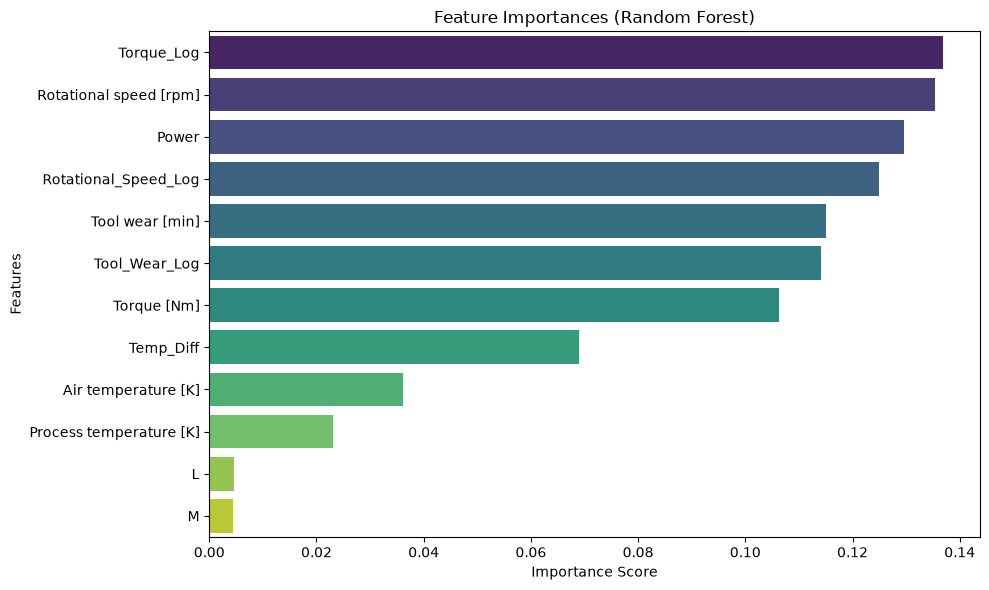

In [ ]:
# STEP 10: DETAILED EVALUATION & FEATURE IMPORTANCE

# 1. Print Detailed Classification Reports
print("="*50)
print("RANDOM FOREST CLASSIFICATION REPORT:")
print("="*50)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

print("="*50)
print("DECISION TREE CLASSIFICATION REPORT:")
print("="*50)
y_pred_dt = model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

print("="*50)
print("LOGISTIC REGRESSION CLASSIFICATION REPORT:")
print("="*50)
y_pred_lr = model_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

# 2. Plot Feature Importance for Random Forest
importances = model_rf.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

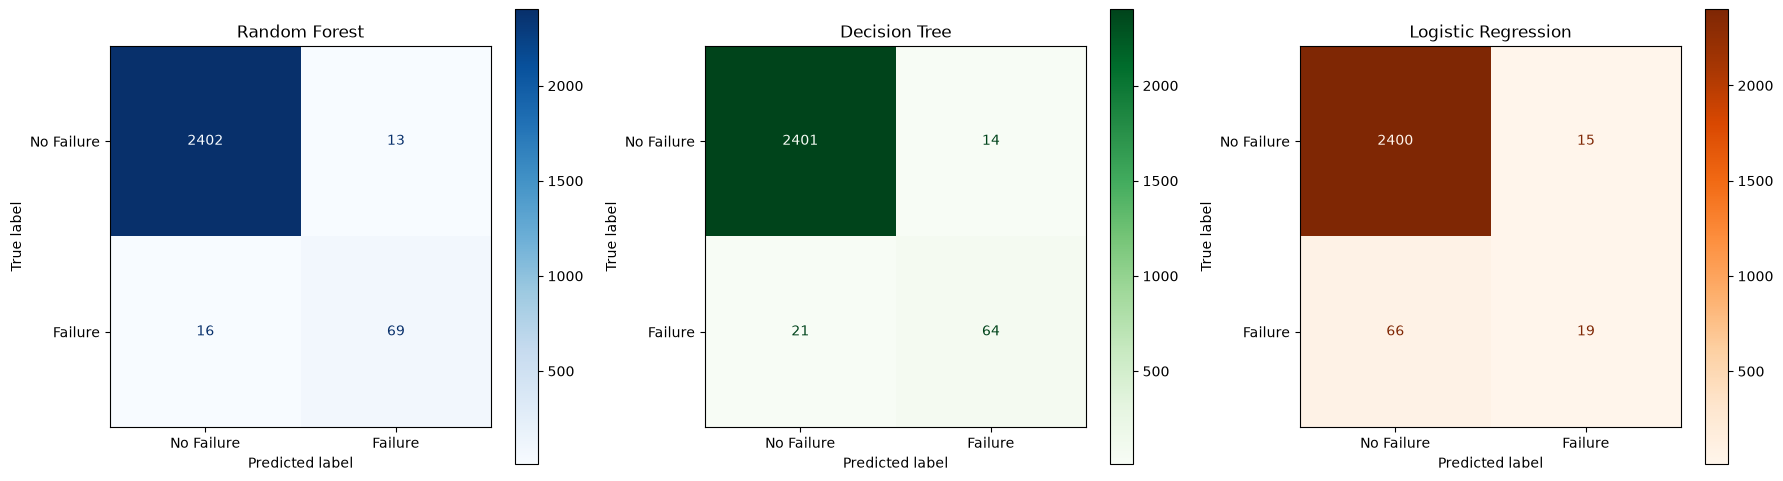

FINAL MODEL ACCURACY COMPARISON
              Model  Accuracy (%)
      Random Forest         98.84
      Decision Tree         98.60
Logistic Regression         96.76


In [ ]:
# STEP 11: CONFUSION MATRIX VISUALIZATION
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Failure', 'Failure'])
disp_rf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Random Forest')

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No Failure', 'Failure'])
disp_dt.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Decision Tree')

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Failure', 'Failure'])
disp_lr.plot(ax=axes[2], cmap='Oranges', values_format='d')
axes[2].set_title('Logistic Regression')

plt.tight_layout()
plt.show()

# Final Summary Table
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree', 'Logistic Regression'],
    'Accuracy (%)': [rf_acc, dt_acc, lr_acc]
})

print("="*40)
print("FINAL MODEL ACCURACY COMPARISON")
print("="*40)
print(results_df.to_string(index=False))

In [ ]:
# STEP 12: SAMPLE INFERENCE & MODEL SAVING
import joblib

# 1. Save the best performing model (Random Forest)
model_filename = 'predictive_maintenance_rf_model.pkl'
joblib.dump(model_rf, model_filename)
print(f"Model successfully saved to '{model_filename}'! 💾")

# 2. Test prediction on a sample from the test set
sample_data = X_test.iloc[:3]
sample_predictions = model_rf.predict(sample_data)
sample_probabilities = model_rf.predict_proba(sample_data)[:, 1]

# Display sample results
inference_df = sample_data.copy()
inference_df['Actual Failure'] = y_test.iloc[:3].values
inference_df['Predicted Failure'] = sample_predictions
inference_df['Failure Probability'] = sample_probabilities.round(4)

print("\nSample Inference Results:")
inference_df[['Actual Failure', 'Predicted Failure', 'Failure Probability']]

Model successfully saved to 'predictive_maintenance_rf_model.pkl'! 💾

Sample Inference Results:


,Actual Failure,Predicted Failure,Failure Probability
1390,0,0,0.0
2925,0,0,0.0
2488,0,0,0.0
